## Multiple Tools

In [1]:
# 1) Sequential tool calls
# 2) Parallel tool calls
# 3) No tool calls

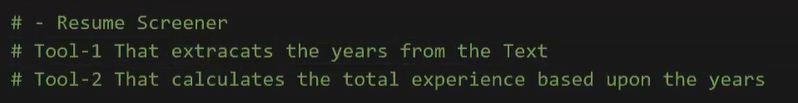

In [5]:
import os
import json
import re
from openai import OpenAI
from dotenv import load_dotenv

In [4]:
load_dotenv()

True

### Step 1: Create Tool 1 (Extract Years)

In [25]:
def extract_years(text):
    years = re.findall(r'\b(19\d{2}|20\d{2})\b', text)
    return [int(i) for i in years]

In [26]:
extract_years_tool = {
    'type': 'function',
    'function': {
        'name': 'extract_years',
        'description': 'Extracts all dates given in the text and returns a Python list.',
        'parameters': {
            'type': 'object',
            'properties': {
                'text': {'type': 'string', 'description': ''}
            },
            'required': ['text']
        }
    }
}

extract_years_tool

{'type': 'function',
 'function': {'name': 'extract_years',
  'description': 'Extracts all dates given in the text and returns a Python list.',
  'parameters': {'type': 'object',
   'properties': {'text': {'type': 'string', 'description': ''}},
   'required': ['text']}}}

### Step 2: Create Tool 2 (Calculate the total experience)

In [27]:
def calculate_experience(years):
    if len(years) < 2:
        return 0
    return max(years) - min(years)

In [32]:
experience_tool = {
    'type': 'function',
    'function': {
        'name': 'calculate_experience',
        'description': 'Calculates the toal experince from the given Python list of years.',
        'parameters': {
            'type': 'object',
            'properties': {
                'years': {'type': 'array', 
                          'items': {'type': 'integer'}}
            },
            'required': ['years']
        }
    }
}

experience_tool

{'type': 'function',
 'function': {'name': 'calculate_experience',
  'description': 'Calculates the toal experince from the given Python list of years.',
  'parameters': {'type': 'object',
   'properties': {'years': {'type': 'array', 'items': {'type': 'integer'}}},
   'required': ['years']}}}